In [3]:
!pip install tensorflow

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential, callbacks
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

In [10]:
import kagglehub
path = kagglehub.dataset_download("rhythmghai/300k-student-performance-prediction-dataset")
file_path = path + "/student_performance_prediction_dataset-2.csv"

Using Colab cache for faster access to the '300k-student-performance-prediction-dataset' dataset.


In [11]:
data = pd.read_csv(file_path)
data.shape

(300000, 25)

In [12]:
data.head()

,student_id,age,gender,study_hours,attendance,sleep_hours,previous_grade,assignments_completed,practice_tests_taken,group_study_hours,...,social_media_hours,family_income,parent_education,internet_access,device_type,school_type,extracurriculars,final_grade,grade_category,pass_fail
0,1,21,Male,1.645404,79.154521,8.230886,96.053840,7.719620,1.871170,1.447894,...,4.018412,Medium,Master,Yes,Mobile,Private,Coding Club,59.248749,D,Pass
1,2,18,Male,4.462126,72.526685,6.139219,53.024821,6.754758,5.630071,1.891288,...,3.268642,Medium,Master,Yes,Laptop,Public,NaN,58.595595,D,Pass
2,3,19,Female,6.220212,98.531716,6.946313,78.775422,10.000000,7.862877,1.774356,...,2.327293,Low,High School,Yes,Tablet,Private,Music,85.855289,A,Pass
3,4,21,Female,1.826644,97.731245,8.297048,76.122618,7.440486,2.316252,1.204271,...,1.163367,Medium,Bachelor,Yes,Laptop,Public,Debate,42.117503,F,Fail
4,5,17,Male,3.789322,78.589107,6.777171,81.305681,9.962609,5.335697,1.399230,...,0.411183,High,High School,Yes,Laptop,Private,Debate,62.870474,C,Pass


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   student_id             300000 non-null  int64  
 1   age                    300000 non-null  int64  
 2   gender                 300000 non-null  object 
 3   study_hours            300000 non-null  float64
 4   attendance             300000 non-null  float64
 5   sleep_hours            300000 non-null  float64
 6   previous_grade         300000 non-null  float64
 7   assignments_completed  300000 non-null  float64
 8   practice_tests_taken   300000 non-null  float64
 9   group_study_hours      300000 non-null  float64
 10  notes_quality_score    300000 non-null  float64
 11  time_management_score  300000 non-null  float64
 12  motivation_level       300000 non-null  float64
 13  mental_health_score    300000 non-null  float64
 14  screen_time            300000 non-nu

In [14]:
data.describe()

,student_id,age,study_hours,attendance,sleep_hours,previous_grade,assignments_completed,practice_tests_taken,group_study_hours,notes_quality_score,time_management_score,motivation_level,mental_health_score,screen_time,social_media_hours,final_grade
count,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000
mean,150000.500000,17.999070,4.503062,84.699395,6.991431,69.840184,7.836044,4.017508,1.529057,6.946017,6.464472,6.945851,6.984210,4.018094,2.530258,53.089206
std,86602.684716,1.999235,1.978513,9.419450,1.463070,14.683157,1.732474,1.956444,0.941525,1.885193,1.925801,1.886246,1.471193,1.958596,1.435742,12.225161
min,1.000000,15.000000,0.000000,40.000000,3.000000,20.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,75000.750000,16.000000,3.143566,78.241008,5.992666,59.870863,6.654817,2.655243,0.826462,5.653740,5.138654,5.655885,5.982593,2.650836,1.491633,44.867737
50%,150000.500000,18.000000,4.498272,84.990371,6.999011,69.955736,8.000829,4.001981,1.499206,7.011212,6.493222,7.005390,6.992543,3.997134,2.498493,53.167495
75%,225000.250000,20.000000,5.843646,91.732244,8.013284,80.102857,9.357154,5.349494,2.172680,8.356150,7.845919,8.356416,8.010331,5.350158,3.513496,61.379373
max,300000.000000,21.000000,12.000000,100.000000,10.000000,100.000000,10.000000,10.000000,5.840593,10.000000,10.000000,10.000000,10.000000,12.000000,8.000000,100.000000


In [15]:
data.isnull().sum()

,0
student_id,0
age,0
gender,0
study_hours,0
attendance,0
sleep_hours,0
previous_grade,0
assignments_completed,0
practice_tests_taken,0
group_study_hours,0


In [16]:
data.duplicated().sum()

np.int64(0)

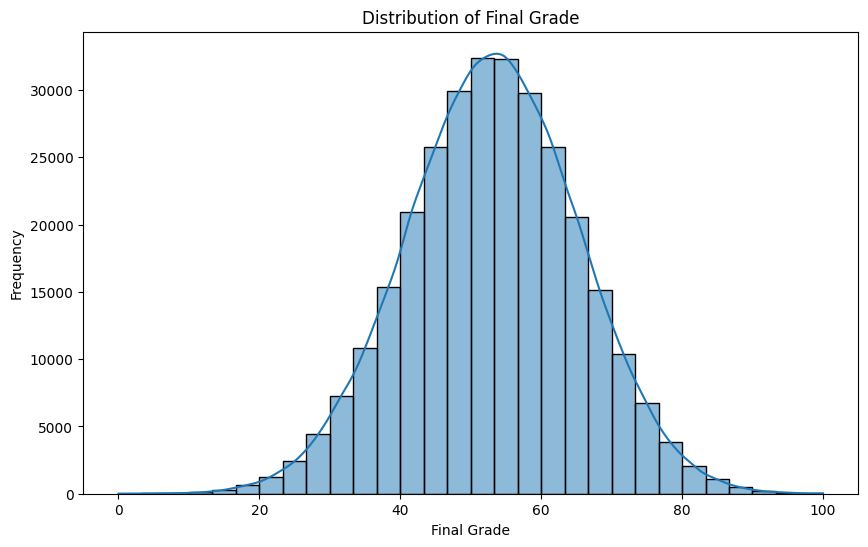

In [17]:
# Target variable distribution
plt.figure(figsize=(10, 6))
sns.histplot(data['final_grade'], bins=30, kde=True)
plt.title('Distribution of Final Grade')
plt.xlabel('Final Grade')
plt.ylabel('Frequency')
plt.show()

In [29]:
data_drop = ['device_type', 'extracurriculars', 'grade_category', 'pass_fail']
clean_data = data.drop(columns=data_drop)

In [30]:
categorical_cols = clean_data.select_dtypes(include=['object']).columns.tolist()
categorical_cols

['gender',
 'family_income',
 'parent_education',
 'internet_access',
 'school_type']

In [32]:
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    clean_data[col] = le.fit_transform(clean_data[col])
    label_encoders[col] = le

print("\nFirst 5 rows after encoding:")
clean_data.head()


First 5 rows after encoding:


,student_id,age,gender,study_hours,attendance,sleep_hours,previous_grade,assignments_completed,practice_tests_taken,group_study_hours,...,time_management_score,motivation_level,mental_health_score,screen_time,social_media_hours,family_income,parent_education,internet_access,school_type,final_grade
0,1,21,1,1.645404,79.154521,8.230886,96.053840,7.719620,1.871170,1.447894,...,7.316867,9.045441,7.762145,1.549443,4.018412,2,2,1,0,59.248749
1,2,18,1,4.462126,72.526685,6.139219,53.024821,6.754758,5.630071,1.891288,...,10.000000,9.810884,4.229670,5.458155,3.268642,2,2,1,1,58.595595
2,3,19,0,6.220212,98.531716,6.946313,78.775422,10.000000,7.862877,1.774356,...,3.618888,10.000000,7.583075,0.000000,2.327293,1,1,1,0,85.855289
3,4,21,0,1.826644,97.731245,8.297048,76.122618,7.440486,2.316252,1.204271,...,5.366866,5.935404,4.978907,5.325794,1.163367,2,0,1,1,42.117503
4,5,17,1,3.789322,78.589107,6.777171,81.305681,9.962609,5.335697,1.399230,...,5.613393,5.431089,5.677695,4.416843,0.411183,0,1,1,0,62.870474


In [34]:
X = clean_data.drop(columns=['final_grade', 'student_id'])
y = clean_data['final_grade']

In [36]:
X.shape

(300000, 19)

In [37]:
y.shape

(300000,)

Train Test Split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [40]:
X_train.shape[0]

240000

In [41]:
X_test.shape[0]

60000

Feature Scaling

In [42]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [61]:
def create_model_relu_adam():
    model = Sequential([
        layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        layers.Dropout(0.2), # turns off 20% of neurons during training to reduce overfitting
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

In [63]:
model1 = create_model_relu_adam()

In [64]:
history1 = model1.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - loss: 88.2006 - mae: 6.5934 - val_loss: 28.9827 - val_mae: 4.2960
Epoch 2/50
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - loss: 37.9430 - mae: 4.8990 - val_loss: 41.4589 - val_mae: 5.1870
Epoch 3/50
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - loss: 30.9284 - mae: 4.4271 - val_loss: 69.6330 - val_mae: 6.9350
Epoch 4/50
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - loss: 29.1666 - mae: 4.3006 - val_loss: 71.1125 - val_mae: 7.0140
Epoch 5/50
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 28.3329 - mae: 4.2421 - val_loss: 58.7648 - val_mae: 6.2829
Epoch 6/50
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 27.7892 - mae: 4.2009 - val_loss: 49.3251 - val_mae: 5.6977
Epoch 7/50
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 27.3695 - mae: 4.1701 - val_loss: 49.8366 - val_mae: 5.7030
Epoch 8/50
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 27.0579 - mae: 4.1463 - val_loss: 43.1893 - val_mae: 5.2846
Epoch 9/50
3000/3

In [65]:
test_loss, test_mae1 = model1.evaluate(X_test_scaled, y_test, verbose=0)
test_mae1

4.537487030029297

In [51]:
def create_model_tanh_sgd():
    model = Sequential([
        layers.Dense(128, activation='tanh', input_shape=(X_train_scaled.shape[1],)),
        layers.Dropout(0.2),
        layers.Dense(64, activation='tanh'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='tanh'),
        layers.Dense(1)
    ])
    model.compile(optimizer='sgd', loss='mse', metrics=['mae', tf.keras.metrics.R2Score(name='r2')])
    return model

In [52]:
model2 = create_model_tanh_sgd()
history2 = model2.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - loss: 37.8468 - mae: 4.5948 - r2: 0.7472 - val_loss: 27.8141 - val_mae: 4.1969 - val_r2: 0.8141
Epoch 2/50
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 28.6559 - mae: 4.2623 - r2: 0.8086 - val_loss: 27.2827 - val_mae: 4.1600 - val_r2: 0.8176
Epoch 3/50
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 28.2734 - mae: 4.2380 - r2: 0.8111 - val_loss: 27.4946 - val_mae: 4.1799 - val_r2: 0.8162
Epoch 4/50
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 27.9532 - mae: 4.2115 - r2: 0.8133 - val_loss: 27.1903 - val_mae: 4.1559 - val_r2: 0.8182
Epoch 5/50
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 27.7407 - mae: 4.1972 - r2: 0.8147 - val_loss: 26.9979 - val_mae: 4.1373 - val_r2: 0.8195
Epoch 6/50
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 27.6730 - mae: 4.1891 - r2: 0.8152 - val_loss: 26.9224 - val_mae: 4.1325 - val_r2: 0.8200
Epoch 7/50
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 27.5732 - mae: 4.182

In [54]:
test_loss2, test_mae2, test_r2_2 = model2.evaluate(X_test_scaled, y_test, verbose=0)
test_mae2

4.089308738708496

In [55]:
test_r2_2

0.8234444856643677

In [56]:
def create_model_sigmoid_rmsprop():
    model = Sequential([
        layers.Dense(128, activation='sigmoid', input_shape=(X_train_scaled.shape[1],)),
        layers.Dropout(0.2),
        layers.Dense(64, activation='sigmoid'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='sigmoid'),
        layers.Dense(1)
    ])
    model.compile(optimizer='rmsprop', loss='mse', metrics=['mae', tf.keras.metrics.R2Score(name='r2')])
    return model

In [57]:
model3 = create_model_sigmoid_rmsprop()

In [73]:
history3 = model3.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    verbose=1
    )

Epoch 1/100
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 25.4646 - mae: 4.0265 - r2: 0.8299 - val_loss: 25.3548 - val_mae: 4.0174 - val_r2: 0.8305
Epoch 2/100
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 25.4755 - mae: 4.0273 - r2: 0.8298 - val_loss: 25.3287 - val_mae: 4.0153 - val_r2: 0.8307
Epoch 3/100
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 25.4929 - mae: 4.0289 - r2: 0.8297 - val_loss: 25.3643 - val_mae: 4.0178 - val_r2: 0.8304
Epoch 4/100
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 25.4934 - mae: 4.0296 - r2: 0.8297 - val_loss: 25.3448 - val_mae: 4.0168 - val_r2: 0.8306
Epoch 5/100
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 25.4810 - mae: 4.0279 - r2: 0.8298 - val_loss: 25.3875 - val_mae: 4.0196 - val_r2: 0.8303
Epoch 6/100
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 25.4454 - mae: 4.0251 - r2: 0.8300 - val_loss: 25.3252 - val_mae: 4.0154 - val_r2: 0.8307
Epoch 7/100
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 25.4381 - mae:

In [74]:
test_loss3, test_mae3, test_r2_3 = model3.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test MAE: {test_mae3:.4f}, Test R²: {test_r2_3:.4f}")

Test MAE: 4.0157, Test R²: 0.8298


Additional Experiments (Different Epochs)

In [75]:
# Experiment with different epochs:
epochs_list = [20, 30, 50, 70, 100]
results = {}

for epochs in epochs_list:
    print(f"\n--- Training with {epochs} epochs ---")
    model = create_model_relu_adam()
    history = model.fit(
        X_train_scaled, y_train,
        epochs=epochs,
        batch_size=64,
        validation_split=0.2,
        verbose=0
    )
    test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)
    results[f"ReLU_Adam_{epochs}"] = test_mae
    print(f"Epochs: {epochs}, Test MAE: {test_mae:.4f}")


--- Training with 20 epochs ---
Epochs: 20, Test MAE: 4.3886

--- Training with 30 epochs ---
Epochs: 30, Test MAE: 4.6278

--- Training with 50 epochs ---
Epochs: 50, Test MAE: 4.6029

--- Training with 70 epochs ---
Epochs: 70, Test MAE: 4.8100

--- Training with 100 epochs ---
Epochs: 100, Test MAE: 4.7324


In [77]:
architectures = [
    {'layers': [64, 32], 'name': 'Small'},
    {'layers': [256, 128, 64], 'name': 'Large'},
    {'layers': [128, 64, 32, 16], 'name': 'Deep'}
]

Experiment with Different Architectures

In [78]:
# for arch in architectures:
#     print(f"\n--- Testing {arch['name']} Architecture ---")
#     model = Sequential()
#     model.add(layers.Dense(arch['layers'][0], activation='relu',
#                           input_shape=(X_train_scaled.shape[1],)))
#     model.add(layers.Dropout(0.2))

#     for neurons in arch['layers'][1:]:
#         model.add(layers.Dense(neurons, activation='relu'))
#         model.add(layers.Dropout(0.2))

#     model.add(layers.Dense(1))
#     model.compile(optimizer='adam', loss='mse', metrics=['mae'])

#     history = model.fit(
#         X_train_scaled, y_train,
#         epochs=50,
#         batch_size=64,
#         validation_split=0.2,
#         verbose=0
#     )
#     test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)
#     print(f"{arch['name']} Architecture - Test MAE: {test_mae:.4f}")


--- Testing Small Architecture ---
Small Architecture - Test MAE: 4.1681

--- Testing Large Architecture ---


KeyboardInterrupt: 

Comparison Table

In [79]:
comparison_data = {
    'Model': ['Model 1', 'Model 2', 'Model 3', 'ReLU_Adam_20', 'ReLU_Adam_30',
              'ReLU_Adam_50', 'Small_Arch', 'Large_Arch', 'Deep_Arch'],
    'Activation': ['ReLU', 'Tanh', 'Sigmoid', 'ReLU', 'ReLU', 'ReLU', 'ReLU', 'ReLU', 'ReLU'],
    'Optimizer': ['Adam', 'SGD', 'RMSprop', 'Adam', 'Adam', 'Adam', 'Adam', 'Adam', 'Adam'],
    'Epochs': [50, 50, 50, 20, 30, 50, 50, 50, 50],
    'Test MAE': [test_mae1, test_mae2, test_mae3,
                 results.get('ReLU_Adam_20', 0),
                 results.get('ReLU_Adam_30', 0),
                 results.get('ReLU_Adam_50', 0),
                 0, 0, 0]  # Replace with actual values
}

comparison_df = pd.DataFrame(comparison_data)
print("\n--- Model Comparison Table ---")
print(comparison_df.to_string(index=False))


--- Model Comparison Table ---
       Model Activation Optimizer  Epochs  Test MAE
     Model 1       ReLU      Adam      50  4.537487
     Model 2       Tanh       SGD      50  4.089309
     Model 3    Sigmoid   RMSprop      50  4.015654
ReLU_Adam_20       ReLU      Adam      20  4.388594
ReLU_Adam_30       ReLU      Adam      30  4.627810
ReLU_Adam_50       ReLU      Adam      50  4.602912
  Small_Arch       ReLU      Adam      50  0.000000
  Large_Arch       ReLU      Adam      50  0.000000
   Deep_Arch       ReLU      Adam      50  0.000000


Training History Visualization

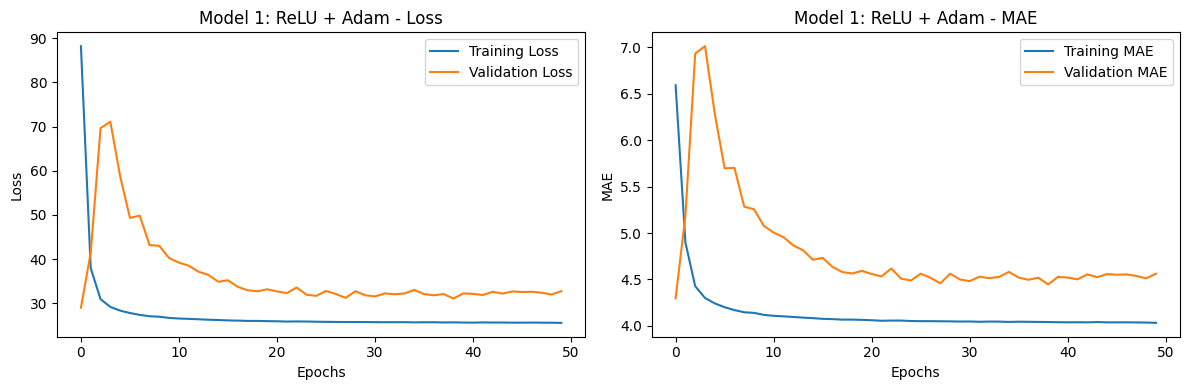

In [80]:
# Plot training history for best model
def plot_training_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    axes[0].plot(history.history['loss'], label='Training Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_title(f'{title} - Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    # MAE
    axes[1].plot(history.history['mae'], label='Training MAE')
    axes[1].plot(history.history['val_mae'], label='Validation MAE')
    axes[1].set_title(f'{title} - MAE')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('MAE')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# Plot for best model (assuming Model 1 is best)
plot_training_history(history1, 'Model 1: ReLU + Adam')

Final Predictions and Evaluation

In [81]:
best_model = model

# predictions on test data
y_pred = best_model.predict(X_test_scaled)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\n--- Best Model Performance ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step

--- Best Model Performance ---
Mean Absolute Error (MAE): 4.2477
Mean Squared Error (MSE): 28.2480
Root Mean Squared Error (RMSE): 5.3149
R² Score: 0.8098


In [82]:
model1.save('best_student_performance_model.h5')

In [83]:
import joblib

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')

['label_encoders.pkl']

In [85]:
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import MeanAbsoluteError, MeanSquaredError

custom_objects = {
    'mse': MeanSquaredError(),
    'mae': MeanAbsoluteError()
}

loaded_model = load_model('best_student_performance_model.h5', custom_objects=custom_objects)

scaler = joblib.load('scaler.pkl')
label_encoders = joblib.load('label_encoders.pkl')

In [86]:
model1.save('/content/relu_adam.keras')

model2.save('/content/tanh_sgd.keras')

best_model.save('/content/best_model.keras')

In [87]:
!pip freeze > /content/requirements.txt